In [22]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

CSV_PATH = Path("pie_grid_evaluation.csv")
T_DELTAS = (0.0, 0.15)
HIGHLIGHT_CELL_RC = (1, 3)  # t_end=0.9, t_start=0.6


def _fmt_metric(v: float) -> str:
    return "n/a" if np.isnan(v) else f"{v:.2f}"


In [23]:
def plot_grid(
    avg_psnr: Dict[Tuple[float, float, float], float],
    avg_clip: Dict[Tuple[float, float, float], float],
    t_start_values: List[float],
    t_end_values: List[float],
    output_file: Path,
    *,
    clip_label: str,
    clip_model: str,
    n_samples: int,
) -> None:
    """Render the t_start x t_end comparison grid and save it to ``output_file``.

    Each block is a 2x2 of subcells: PSNR on top, CLIP on bottom, with t_delta=0
    on the left and t_delta=0.15 on the right. Within each top/bottom pair the
    larger value is shaded green and the smaller grey (white when both are
    missing). The block at :data:`HIGHLIGHT_CELL_RC` is outlined as a reference
    operating point. x is t_start, y is t_end.
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    n_rows = len(t_end_values)
    n_cols = len(t_start_values)

    GOOD = "#b6e8b6"
    PLAIN = "#f0f0f0"
    EMPTY = "white"
    BORDER = "gray"

    internal_gap = 0.06
    sub = (1 - internal_gap) / 2  # subcell size in block-data coords
    td0, td15 = T_DELTAS

    def pick(v0: float, v15: float) -> Tuple[str, str]:
        """Return (color_for_delta0, color_for_delta0.15): green for the larger
        value, grey for the smaller, white when a value is missing."""
        if np.isnan(v0) and np.isnan(v15):
            return EMPTY, EMPTY
        if np.isnan(v0):
            return EMPTY, GOOD
        if np.isnan(v15):
            return GOOD, EMPTY
        if v0 > v15:
            return GOOD, PLAIN
        if v15 > v0:
            return PLAIN, GOOD
        return EMPTY, EMPTY

    fig, ax = plt.subplots(figsize=(n_cols + 2, n_rows + 2))

    for row_i, t_end in enumerate(t_end_values):
        for col_j, t_start in enumerate(t_start_values):
            psnr0 = avg_psnr.get((t_start, t_end, td0), float("nan"))
            psnr15 = avg_psnr.get((t_start, t_end, td15), float("nan"))
            clip0 = avg_clip.get((t_start, t_end, td0), float("nan"))
            clip15 = avg_clip.get((t_start, t_end, td15), float("nan"))

            psnr_c0, psnr_c15 = pick(psnr0, psnr15)
            clip_c0, clip_c15 = pick(clip0, clip15)

            subcells = [  # dx, dy, color, label
                (0, sub, psnr_c0, "P$_0$:" + _fmt_metric(psnr0)),
                (sub, sub, psnr_c15, "P$_{15}$:" + _fmt_metric(psnr15)),
                (0, 0, clip_c0, "C$_0$:" + _fmt_metric(clip0)),
                (sub, 0, clip_c15, "C$_{15}$:" + _fmt_metric(clip15)),
            ]

            highlight = HIGHLIGHT_CELL_RC == (row_i, col_j)
            for dx, dy, color, label in subcells:
                x = col_j + dx
                y = row_i + dy
                ax.add_patch(Rectangle(
                    (x, y), sub, sub,
                    facecolor=color,
                    edgecolor="black" if highlight else BORDER,
                    lw=0.8 if highlight else 0.5,
                ))
                ax.text(
                    x + sub / 2, y + sub / 2, label,
                    ha="center", va="center",
                    family="monospace", fontsize=6,
                )

    margin = internal_gap
    ax.set(xlim=(-margin, n_cols), ylim=(-margin, n_rows), aspect="equal")

    ax.set_xticks([col + 0.5 for col in range(n_cols)])
    ax.set_xticklabels([f"{v:.2f}" for v in t_start_values], fontsize=8)
    ax.set_yticks([row + 0.5 for row in range(n_rows)])
    ax.set_yticklabels([f"{v:.2f}" for v in t_end_values], fontsize=8)
    ax.tick_params(axis="both", which="both", length=0, pad=4)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlabel("t_start", fontsize=9, labelpad=6)
    ax.set_ylabel("t_end", fontsize=9, labelpad=6)
    ax.set_title(
        f"PIE-Bench mean PSNR and {clip_label} comparison over t-values, "
        f"d=0 and d=0.15\nwhere n_samples={n_samples}, model={clip_model.split('/')[-1]}",
        fontsize=8, pad=6,
    )

    output_file.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_file, dpi=150, bbox_inches="tight")
    print(f"\nSaved to {output_file}")




Saved to pie_grid.png


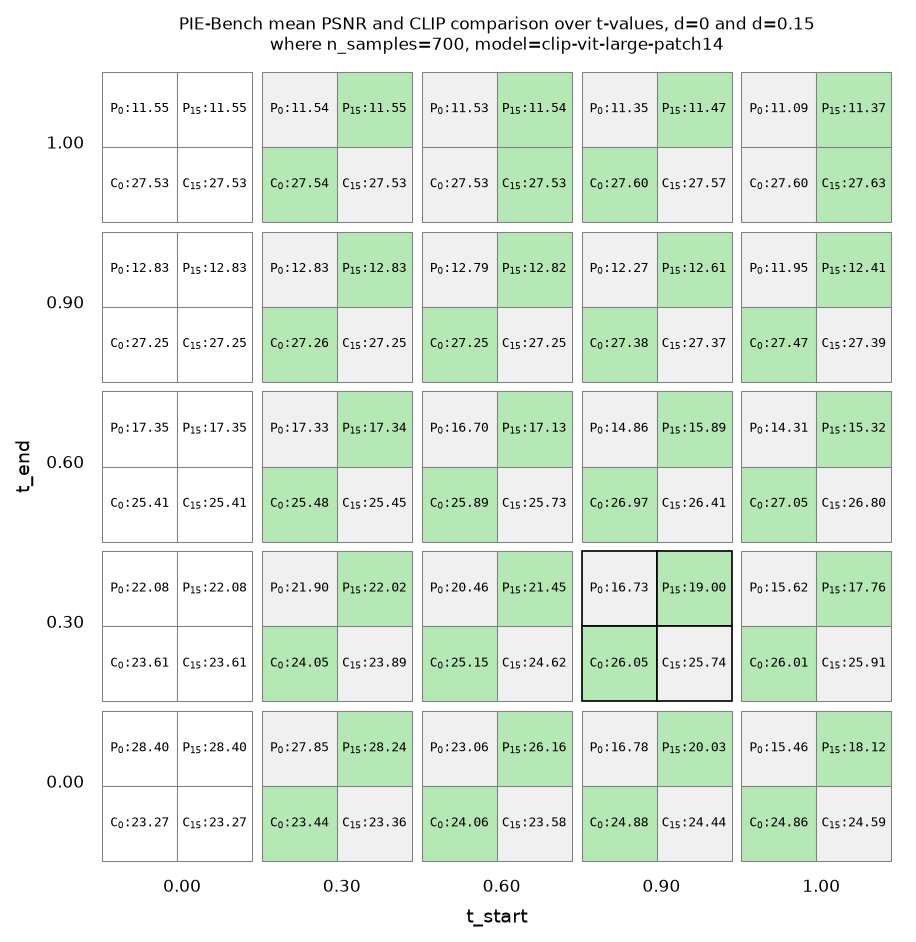

In [24]:
df = pd.read_csv(CSV_PATH)

grouped = (
    df.groupby(["t_start", "t_end", "t_delta"])[["psnr", "clip_similarity_target_image"]]
    .mean()
)

avg_psnr = {
    (ts, te, td): row["psnr"]
    for (ts, te, td), row in grouped.iterrows()
}
avg_clip = {
    (ts, te, td): row["clip_similarity_target_image"]
    for (ts, te, td), row in grouped.iterrows()
}

t_start_values = sorted(df["t_start"].unique())
t_end_values = sorted(df["t_end"].unique())
n_samples = int(df.groupby(["t_start", "t_end", "t_delta"]).size().iloc[0])

output_file = Path("pie_grid.png")

plot_grid(
    avg_psnr,
    avg_clip,
    t_start_values,
    t_end_values,
    output_file,
    clip_label="CLIP",
    clip_model="openai/clip-vit-large-patch14",
    n_samples=n_samples,
)

from IPython.display import Image
Image(str(output_file))
